# Token Probability Approach

In [1]:
SEED = 4

## Connect to your Google Drive or any filesystem you are going to use.

In [2]:
"""
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/gdrive")
base_path = (
    Path("your_path") if IN_COLAB else Path(".")
)

#Fix if you want to use a different path
output_path = base_path / "output"
data_path = base_path / "HaluEval"
output_path.mkdir(exist_ok=True)
"""

'\nimport sys\nfrom pathlib import Path\n\nIN_COLAB = "google.colab" in sys.modules\nif IN_COLAB:\n    from google.colab import drive\n\n    drive.mount("/content/gdrive")\nbase_path = (\n    Path("your_path") if IN_COLAB else Path(".")\n)\n\n#Fix if you want to use a different path\noutput_path = base_path / "output"\ndata_path = base_path / "HaluEval"\noutput_path.mkdir(exist_ok=True)\n'

## These are the libraries needed to run this notebook

## Deep Learning Installations

In [3]:
%pip install transformers datasets evaluate rouge_score
%pip install --upgrade huggingface_hub
"""
%pip install accelerate -U
%pip install transformers[torch]
%pip install sentencepiece
%pip install google
%pip install protobuf
"""

'\n%pip install accelerate -U\n%pip install transformers[torch]\n%pip install sentencepiece\n%pip install google\n%pip install protobuf\n'


## Libraries

In [4]:
SEED = 4

In [5]:
from datasets import load_dataset
from datasets import Dataset
from transformers import AutoTokenizer
from transformers import DataCollatorForSeq2Seq
from transformers import pipeline
from transformers import AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer
from transformers import AutoTokenizer
from transformers import AutoModelForSeq2SeqLM
import numpy as np
np.random.seed(SEED)
import pandas as pd
import evaluate
import random
import json
import matplotlib.pyplot as plt
import seaborn as sns


# Reading Dataset

`The method loadDataset receieves the path where the datasets json files of the HaluEval repository are. You just need to pass your path and the name of the dataset you are going to use.`

## Dataset Names:
- summarization
- dialogue
- qa
- general


In [6]:
## As a recomendation keep these two with the same naming if you do not want to change many things
datasetName = "general"
task = datasetName

In [7]:
import requests

base_url = "https://raw.githubusercontent.com/RUCAIBox/HaluEval-2.0/master/annotation/human_annotation/"


bio_medical = requests.get(base_url + "Bio-Medical.json").json()
education = requests.get(base_url + "Education.json").json()
finance = requests.get(base_url + "Finance.json").json()
open_domain = requests.get(base_url + "Open-Domain.json").json()
science = requests.get(base_url + "Science.json").json()

In [8]:
"""
def loadDataset(datasetName, path=data_path):
    file_path = path / f"{datasetName}.json"
    return pd.read_json(file_path) #, lines=True)
"""

'\ndef loadDataset(datasetName, path=data_path):\n    file_path = path / f"{datasetName}.json"\n    return pd.read_json(file_path) #, lines=True)\n'

In [9]:
"""
bio_medical = loadDataset(datasetName="Bio-Medical")
education = loadDataset(datasetName="Education")
finance = loadDataset(datasetName="Finance")
open_domain = loadDataset(datasetName="Open-Domain")
science = loadDataset(datasetName="Science")
"""

'\nbio_medical = loadDataset(datasetName="Bio-Medical")\neducation = loadDataset(datasetName="Education")\nfinance = loadDataset(datasetName="Finance")\nopen_domain = loadDataset(datasetName="Open-Domain")\nscience = loadDataset(datasetName="Science")\n'

### Saving the above file with combined domains

In [10]:
def process_and_save(datasets_dict):

    # 1. Add domain column
    for name, df in datasets_dict.items():
        df["domain"] = name

    # 2. Merge all datasets
    data = pd.concat(datasets_dict.values(), ignore_index=True)

    # 3. Create hallucination label
    def get_label(judges):
        if not isinstance(judges, list) or len(judges) == 0:
            return "unknown"
        judges = [str(j).strip().lower() for j in judges]
        return "yes" if "false" in judges else "no"

    data["hallucination_label"] = data["human_judge"].apply(get_label)

    # 4. Keep only required columns
    data = data[[
        "id",
        "user_query",
        "chatgpt_response",
        "hallucination_label",
        "domain"
    ]]

    # 5. Shuffle
    data = data.sample(frac=1, random_state=SEED).reset_index(drop=True)

    return data

In [11]:
import pandas as pd

datasets = {
    "education": pd.DataFrame(education),
    "bio_medical": pd.DataFrame(bio_medical),
    "finance": pd.DataFrame(finance),
    "open_domain": pd.DataFrame(open_domain),
    "science": pd.DataFrame(science)
}

data = process_and_save(datasets)

In [12]:
data.head()

,id,user_query,chatgpt_response,hallucination_label,domain
0,2083,What is the year that both Gauhar Ali and Ifti...,Gauhar Ali and Iftikhar Ahmed have never been ...,yes,open_domain
1,3264,"In a reverse split, what happens to odd lots?","In a reverse stock split, odd lots typically r...",yes,finance
2,3533,Elijah Connor was part of the spin-off of what...,Elijah Connor was part of the spin-off of the ...,yes,open_domain
3,4063,Which filmmaker has directed more feature film...,Stephen Hopkins has directed more feature film...,no,open_domain
4,2371,“International credit report” for French natio...,"As of my knowledge in August 2021, there is no...",no,finance


## For this particular example we are loading the general_data.json since is the one that takes the less time to process in case you want to test quickly how it works.

### Data Statistics

In [13]:
len(data)

1000

domain
open_domain    200
finance        200
science        200
education      200
bio_medical    200
Name: count, dtype: int64
domain
open_domain    20.0
finance        20.0
science        20.0
education      20.0
bio_medical    20.0
Name: count, dtype: float64


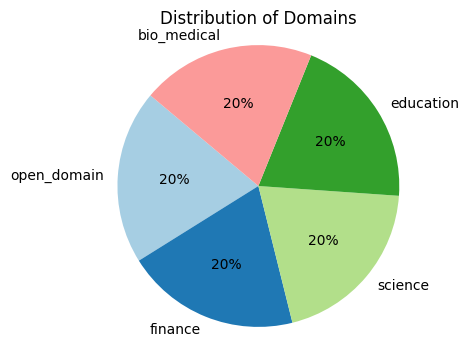

In [14]:
# Get the counts of each unique value in 'domain'
domain_counts = data['domain'].value_counts()
domain_percent = domain_counts/len(data) * 100

print(domain_counts)
print(domain_percent)


domain_counts = data['domain'].value_counts()


plt.figure(figsize=(4, 4))
plt.pie(domain_counts, labels=domain_counts.index, autopct='%1.f%%', startangle=140, colors= plt.cm.Paired.colors)
plt.title('Distribution of Domains')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

hallucination_label
yes        896
no          80
unknown     24
Name: count, dtype: int64
hallucination_label
yes        89.6
no          8.0
unknown     2.4
Name: count, dtype: float64


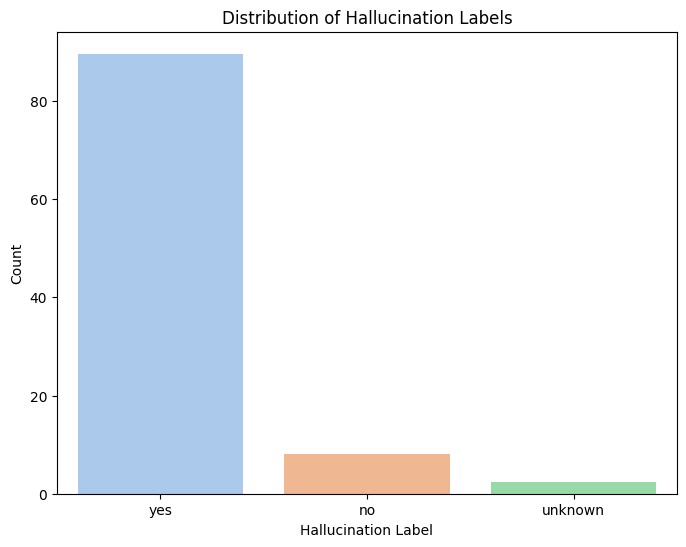

In [15]:
# Get the counts of each unique value in 'hallucination_label'
hallucination_counts = data['hallucination_label'].value_counts()
hallucination_percent = hallucination_counts/len(data) * 100

print(hallucination_counts)
print(hallucination_percent)

# Create a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=hallucination_percent.index, y=hallucination_percent.values, hue=hallucination_counts.index, palette='pastel', legend=False)
plt.title('Distribution of Hallucination Labels')
plt.xlabel('Hallucination Label')
plt.ylabel('Count')
plt.show()

### Hallucination Labels by Domain

In [16]:
hallucination_by_domain = data.groupby('domain')['hallucination_label'].value_counts().unstack(fill_value=0)
display(hallucination_by_domain)

hallucination_label,no,unknown,yes
domain,,,
bio_medical,5,9,186
education,17,3,180
finance,46,1,153
open_domain,5,10,185
science,7,1,192


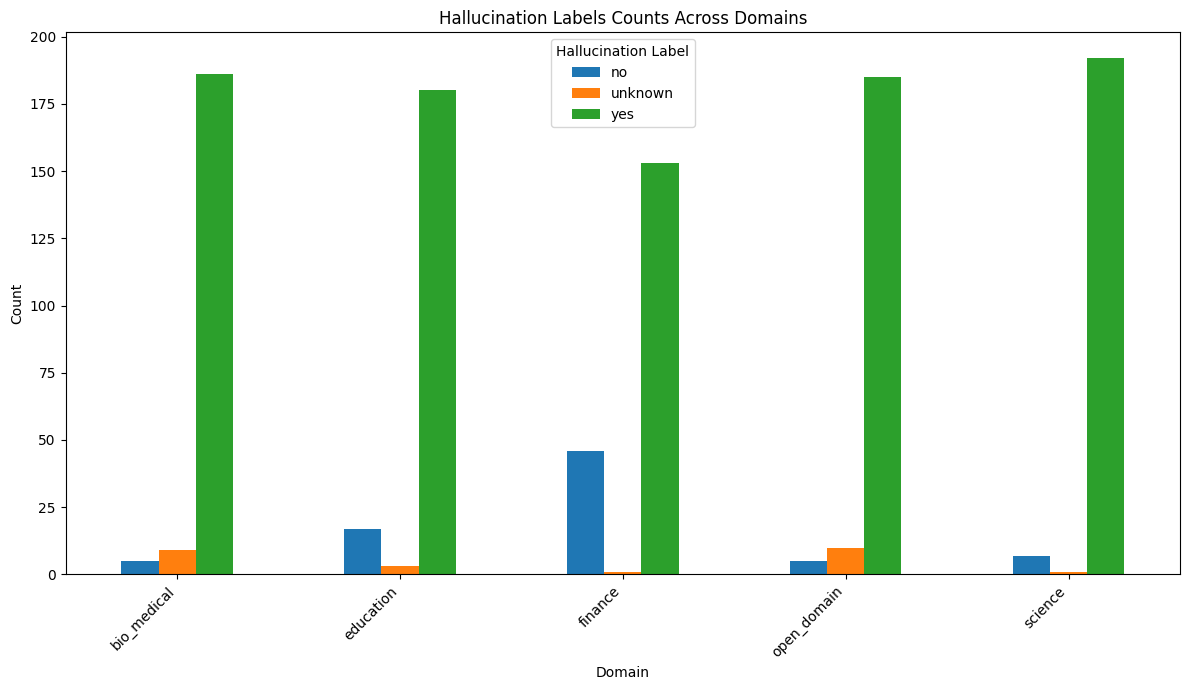

In [17]:
hallucination_by_domain.plot(kind='bar', figsize=(12, 7))
plt.title('Hallucination Labels Counts Across Domains')
plt.xlabel('Domain')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Hallucination Label')
plt.tight_layout()
plt.show()

In [18]:
data = data[data['hallucination_label'] != 'unknown']

# Display the new counts to verify the removal
print(data['hallucination_label'].value_counts())

hallucination_label
yes    896
no      80
Name: count, dtype: int64


In [19]:
hallucination_by_domain = data.groupby('domain')['hallucination_label'].value_counts().unstack(fill_value=0)
display(hallucination_by_domain)

hallucination_label,no,yes
domain,,
bio_medical,5,186
education,17,180
finance,46,153
open_domain,5,185
science,7,192


In [20]:
data.head()

,id,user_query,chatgpt_response,hallucination_label,domain
0,2083,What is the year that both Gauhar Ali and Ifti...,Gauhar Ali and Iftikhar Ahmed have never been ...,yes,open_domain
1,3264,"In a reverse split, what happens to odd lots?","In a reverse stock split, odd lots typically r...",yes,finance
2,3533,Elijah Connor was part of the spin-off of what...,Elijah Connor was part of the spin-off of the ...,yes,open_domain
3,4063,Which filmmaker has directed more feature film...,Stephen Hopkins has directed more feature film...,no,open_domain
4,2371,“International credit report” for French natio...,"As of my knowledge in August 2021, there is no...",no,finance


### Token Size of Chat gpt response

In [21]:
data['chatgpt_response_length'] = data['chatgpt_response'].str.split().apply(len)
#display(data.head())

average_response_length_by_domain = data.groupby('domain')['chatgpt_response_length'].mean().sort_values(ascending=False)
display(average_response_length_by_domain)

,chatgpt_response_length
domain,
science,280.120603
finance,187.763819
bio_medical,125.052356
education,100.771574
open_domain,19.073684


/tmp/ipykernel_44501/2527565532.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_response_length_by_domain.index, y=average_response_length_by_domain.values, palette='viridis')


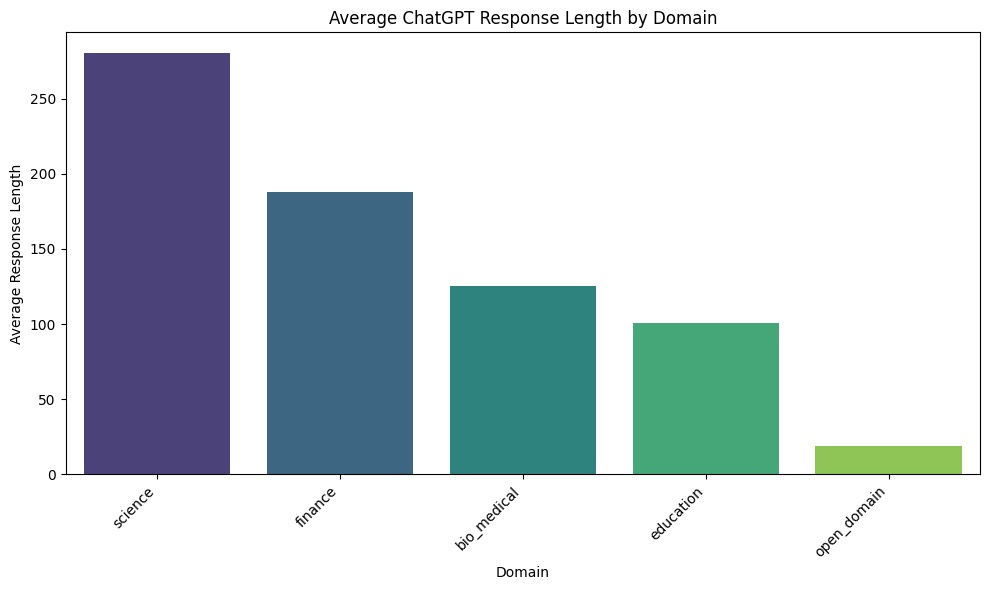

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(x=average_response_length_by_domain.index, y=average_response_length_by_domain.values, palette='viridis')
plt.title('Average ChatGPT Response Length by Domain')
plt.xlabel('Domain')
plt.ylabel('Average Response Length')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Balancing the classes from dataset

In [23]:
data = data[data["hallucination_label"] != "unknown"]

df_yes = data[data["hallucination_label"] == "yes"]
df_no  = data[data["hallucination_label"] == "no"]

n = len(df_no)

data = pd.concat([
    df_yes.sample(n=n, random_state=SEED),
    df_no
]).sample(frac=1, random_state=SEED)  # shuffle

In [24]:
data.head()

,id,user_query,chatgpt_response,hallucination_label,domain,chatgpt_response_length
256,224,How to categorize shared income?,Shared income can be categorized in different ...,yes,finance,352
713,5173,"according to this strategy , if you win your f...","According to the strategy that you mentioned, ...",no,education,25
252,2343,Where can I find the dividend history for a st...,You can find the dividend history for a stock ...,yes,finance,192
586,2321,How does the bank/IRS know whether a bank tran...,"When a bank transfer of over $14k occurs, the ...",no,finance,241
659,1456,What physician and biologist became well-known...,The physician and biologist who became well-kn...,yes,open_domain,29


In [25]:
len(data)

160

hallucination_label
yes    80
no     80
Name: count, dtype: int64
hallucination_label
yes    50.0
no     50.0
Name: count, dtype: float64


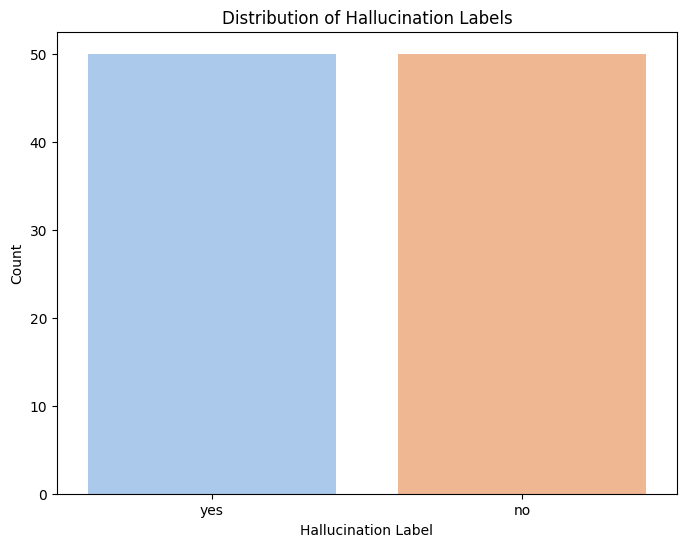

In [26]:
# Get the counts of each unique value in 'hallucination_label'
hallucination_counts = data['hallucination_label'].value_counts()
hallucination_percent = hallucination_counts/len(data) * 100

print(hallucination_counts)
print(hallucination_percent)

# Create a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=hallucination_percent.index, y=hallucination_percent.values, hue=hallucination_counts.index, palette='pastel', legend=False)
plt.title('Distribution of Hallucination Labels')
plt.xlabel('Hallucination Label')
plt.ylabel('Count')
plt.show()

domain
finance        60
education      34
bio_medical    27
science        21
open_domain    18
Name: count, dtype: int64
domain
finance        37.500
education      21.250
bio_medical    16.875
science        13.125
open_domain    11.250
Name: count, dtype: float64


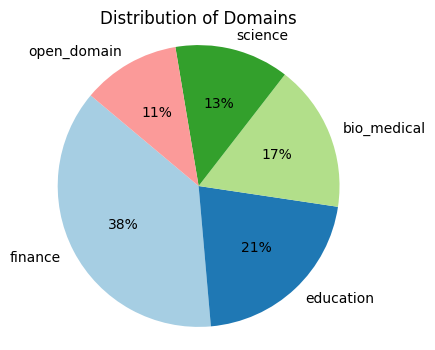

In [27]:
# Get the counts of each unique value in 'domain'
domain_counts = data['domain'].value_counts()
domain_percent = domain_counts/len(data) * 100

print(domain_counts)
print(domain_percent)


domain_counts = data['domain'].value_counts()


plt.figure(figsize=(4, 4))
plt.pie(domain_counts, labels=domain_counts.index, autopct='%1.f%%', startangle=140, colors= plt.cm.Paired.colors)
plt.title('Distribution of Domains')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [28]:
data['chatgpt_response_length'] = data['chatgpt_response'].str.split().apply(len)
#display(data.head())

average_response_length_by_domain = data.groupby('domain')['chatgpt_response_length'].mean().sort_values(ascending=False)
display(average_response_length_by_domain)

,chatgpt_response_length
domain,
science,281.428571
finance,207.400000
bio_medical,97.555556
education,63.617647
open_domain,25.944444


# Setting Device to use the GPU

We use the T4 GPU in Colab since the heaviest computation for us is the inference of the LLM-Evaluator. Therefore, T4 seem as the better fit.

In [29]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Generic LLMModel class to reuse the functionality of extracting the features.


In [31]:
from transformers import BartForConditionalGeneration, BartTokenizer
from transformers import T5Tokenizer, T5ForConditionalGeneration
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from transformers import BartForConditionalGeneration, PegasusForConditionalGeneration
from transformers import LEDForConditionalGeneration, LEDTokenizer
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from transformers import LlamaForCausalLM, LlamaTokenizer

import torch
import torch.nn.functional as F
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


class LLMModel:
    def __init__(self):
        self.model = self.model.to(device)
        pass

    def getName(self) -> str:
        return self.model_name

    def getSanitizedName(self) -> str:
        return self.model_name.replace("/", "__")

    def generate(self, inpt):
        pass

    # Move in future commits this method to an utils.py
    def truncate_string_by_len(self, s, truncate_len):
        words = s.split()
        truncated_words = words[:-truncate_len] if truncate_len > 0 else words
        return " ".join(truncated_words)

    # Method to get the vocabulary probabilities of the LLM for a given token on the generated text from LLM-Generator
    def getVocabProbsAtPos(self, pos, token_probs):
        sorted_probs, sorted_indices = torch.sort(token_probs[pos, :], descending=True)
        return sorted_probs

    def getMaxLength(self):
        return self.model.config.max_position_embeddings

    # By default knowledge is the empty string. If you want to add extra knowledge you can do it like in the cases of the qa_data.json and dialogue_data.json
    def extractFeatures(
        self,
        knowledge="",
        conditionted_text="",
        generated_text="",
        features_to_extract={},
    ):
        self.model.eval()

        total_len = len(knowledge) + len(conditionted_text) + len(generated_text)
        truncate_len = min(total_len - self.tokenizer.model_max_length, 0)

        # Truncate knowledge in case is too large
        knowledge = self.truncate_string_by_len(knowledge, truncate_len // 2)
        # Truncate text_A in case is too large
        conditionted_text = self.truncate_string_by_len(
            conditionted_text, truncate_len - (truncate_len // 2)
        )

        inputs = self.tokenizer(
            [knowledge + conditionted_text + generated_text],
            return_tensors="pt",
            max_length=self.getMaxLength(),
            truncation=True,
        )

        for key in inputs:
            inputs[key] = inputs[key].to(device)

        with torch.no_grad():
            outputs = self.model(**inputs)
            logits = outputs.logits

        probs = F.softmax(logits, dim=-1)
        probs = probs.to(device)

        tokens_generated_length = len(self.tokenizer.tokenize(generated_text))
        start_index = logits.shape[1] - tokens_generated_length
        conditional_probs = probs[0, start_index :]

        token_ids_generated = inputs["input_ids"][0, start_index :].tolist()
        token_probs_generated = [
            conditional_probs[i, tid].item()
            for i, tid in enumerate(token_ids_generated)
        ]

        tokens_generated = self.tokenizer.convert_ids_to_tokens(token_ids_generated)

        minimum_token_prob = min(token_probs_generated)
        average_token_prob = sum(token_probs_generated) / len(token_probs_generated)

        maximum_diff_with_vocab = -1
        minimum_vocab_extreme_diff = 100000000000

        if features_to_extract["MDVTP"] == True or features_to_extract["MMDVP"] == True:
            size = len(token_probs_generated)
            for pos in range(size):
                vocabProbs = self.getVocabProbsAtPos(pos, conditional_probs)
                maximum_diff_with_vocab = max(
                    [
                        maximum_diff_with_vocab,
                        self.getDiffVocab(vocabProbs, token_probs_generated[pos]),
                    ]
                )
                minimum_vocab_extreme_diff = min(
                    [
                        minimum_vocab_extreme_diff,
                        self.getDiffMaximumWithMinimum(vocabProbs),
                    ]
                )

        # allFeatures = [minimum_token_prob, average_token_prob, maximum_diff_with_vocab, minimum_vocab_extreme_diff]

        allFeatures = {
            "mtp": minimum_token_prob,
            "avgtp": average_token_prob,
            "MDVTP": maximum_diff_with_vocab,
            "MMDVP": minimum_vocab_extreme_diff,
        }

        selectedFeatures = {}
        for key, feature in features_to_extract.items():
            if feature == True:
                selectedFeatures[key] = allFeatures[key]

        return selectedFeatures

    def getDiffVocab(self, vocabProbs, tprob):
        return (vocabProbs[0] - tprob).item()

    def getDiffMaximumWithMinimum(self, vocabProbs):
        return (vocabProbs[0] - vocabProbs[-1]).item()

## Definition of the specific Models

In [32]:
class Gemma(LLMModel):
    def __init__(self):
        self.model_name = "google/gemma-7b-it"
        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name
        )
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        super().__init__()


    def generate(self, inpt):
        inputs = self.tokenizer(
            [inpt], max_length=self.getMaxLength(), return_tensors="pt", truncation=True
        )
        summary_ids = self.model.generate(inputs["input_ids"])

        summary = self.tokenizer.decode(summary_ids[0], skip_special_tokens=True)

        return summary


class LLama(LLMModel):
    def __init__(self):
        self.model_name = "meta-llama/Llama-2-7b-chat-hf"
        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
        )
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        super().__init__()


    def generate(self, inpt):
        inputs = self.tokenizer(
            [inpt], max_length=1024, return_tensors="pt", truncation=True
        )
        summary_ids = self.model.generate(inputs["input_ids"])

        summary = self.tokenizer.decode(summary_ids[0], skip_special_tokens=True)

        return summary


class Opt(LLMModel):
    def __init__(self):
        self.model_name = "facebook/opt-6.7b"
        self.model = AutoModelForCausalLM.from_pretrained(self.model_name)
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        super().__init__()


    def generate(self, inpt):
        inputs = self.tokenizer(
            [inpt], max_length=self.getMaxLength(), return_tensors="pt", truncation=True
        )
        summary_ids = self.model.generate(inputs["input_ids"])

        summary = self.tokenizer.decode(summary_ids[0], skip_special_tokens=True)

        return summary


class Gptj(LLMModel):
    def __init__(self):
        self.model_name = "EleutherAI/gpt-j-6B"
        self.model = AutoModelForCausalLM.from_pretrained(self.model_name)
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        super().__init__()


    def generate(self, inpt):
        inputs = self.tokenizer(
            [inpt], max_length=self.getMaxLength(), return_tensors="pt", truncation=True
        )
        summary_ids = self.model.generate(inputs["input_ids"])

        summary = self.tokenizer.decode(summary_ids[0], skip_special_tokens=True)

        return summary


class BartCNN(LLMModel):
    def __init__(self):
        self.model_name = "facebook/bart-large-cnn"
        self.model = BartForConditionalGeneration.from_pretrained(self.model_name)
        self.tokenizer = BartTokenizer.from_pretrained(self.model_name)
        super().__init__()


    def generate(self, inpt):
        inputs = self.tokenizer(
            [inpt], max_length=self.getMaxLength(), return_tensors="pt", truncation=True
        )
        summary_ids = self.model.generate(inputs["input_ids"])

        summary = self.tokenizer.decode(summary_ids[0], skip_special_tokens=True)

        return summary

class GPT2Generator(LLMModel):
    def __init__(self):
        self.model_name = "gpt2-large"
        self.model = GPT2LMHeadModel.from_pretrained(self.model_name)
        self.tokenizer = GPT2Tokenizer.from_pretrained(self.model_name)
        super().__init__()

    def generate(self, inpt):
        inputs = self.tokenizer.encode(
            inpt, return_tensors="pt", max_length=self.getMaxLength(), truncation=True
        )
        output_ids = self.model.generate(
            inputs, max_length=1024, num_return_sequences=1
        )
        output = self.tokenizer.decode(output_ids[0], skip_special_tokens=True)
        return output


class LED(LLMModel):
    def __init__(self):
        self.model_name = "allenai/led-large-16384-arxiv"
        self.model = LEDForConditionalGeneration.from_pretrained(self.model_name)
        self.tokenizer = LEDTokenizer.from_pretrained(self.model_name)
        super().__init__()

    def generate(self, inpt):
        inputs = self.tokenizer(
            [inpt], max_length=self.getMaxLength(), return_tensors="pt", truncation=True
        )
        summary_ids = self.model.generate(inputs["input_ids"])

        summary = self.tokenizer.decode(summary_ids[0], skip_special_tokens=True)

        return summary

# The Dictionary `features_to_extract` defines which features will be use in this experiment.

## Features Meaning:

- `mtp` : Take the minimum of the probabilities that the LLM_E gives to the tokens on the generated-text.
- `avgtp` : Take the average of the probabilities that the LLM_E
gives to the tokens on the generated-text.
- `MDVTP` : Take the maximum from all the differences
between the token with the highest probability
according to LLM_E at position i and the
assigned probability from LLM_E to the token at position i in the generated_text.
- `MMDVP` : Take the maximum from all the differences between the token with the highest probability according to $LLM_E$ at position $i$ ($v^*$) and the token with the lowest probability according to $LLM_E$ at position $i$ ($v^-$).


In [33]:
feature_to_extract = 'all'

available_features_to_extract = ["mtp", "avgtp", "MDVTP", "MMDVP"]
if feature_to_extract == 'all':
    features_to_extract = {
        feature: True for feature in available_features_to_extract
    }
else:
    features_to_extract = {
        feature: True if feature == feature_to_extract else False
        for feature in available_features_to_extract
    }

features_to_extract

{'mtp': True, 'avgtp': True, 'MDVTP': True, 'MMDVP': True}

## Cleaning Cache on GPU to save memory

In [34]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

## This cell is to instantiate the model you intend to use for the experiment

In [35]:
# model = BartCNN()
# model = LED()
model = GPT2Generator()
# model = LLama()
# model = Gemma()
# model = Opt()
# model = Gptj()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

## This cell creates the dataset separation of `10%` for training and `90%` for testing depending on what task you are addressing. The following explanation is what happens if summarization is the task used. But the same explanation applies to all tasks and also you cand pass as parameter how many data points you want to include in training.

## Example: The data is separated on 2000 (1000 of document with right summary and 1000 with the same document but with the hallucinated summary). The rest which is 18000 is used to for testing.

### As expected from previous cells the task string expected are:
- `summarization`
- `qa`
- `dialogue`
- `general`

In [36]:
import random


# Load the data depending on the task
def loadRowData(taskName, row, includeKnowledge=False):
    if taskName == "summarization":
        return "", row["document"], row["right_summary"], row["hallucinated_summary"]
    elif taskName == "qa":
        if includeKnowledge:
            return (
                row["knowledge"],
                row["question"],
                row["right_answer"],
                row["hallucinated_answer"],
            )
        else:
            return "", row["question"], row["right_answer"], row["hallucinated_answer"]

    elif taskName == "dialogue":
        if includeKnowledge:
            return (
                row["knowledge"],
                row["dialogue_history"],
                row["right_response"],
                row["hallucinated_response"],
            )
        else:
            return (
                "",
                row["dialogue_history"],
                row["right_response"],
                row["hallucinated_response"],
            )

    elif taskName == "general":
        return (
            "",
            row["user_query"],
            row["chatgpt_response"],
            row["hallucination_label"],
        )

    else:
        raise Exception("Task not supported")


# Adapt the dataset to have a data point of conditioned-text with right-generation and another with the same conditioned-text and tha hallucinated answer.
def adaptDataset(data, taskName):
    datasetAdapted = None
    if taskName == "general":
        # There is data point that is filling the <mask> token but that gives error with some LLMs
        datasetAdapted = [
            (
                (knowledge, document, response, 1)
                if hallu == "yes"
                else (knowledge, document, response, 0)
            )
            for knowledge, document, response, hallu in data
            if "<mask>" not in document and "<mask>" not in response
        ]

    elif taskName == "summarization" or taskName == "qa" or taskName == "dialogue":
        datasetAdapted = [
            (knowledge, document, right, 1)
            for knowledge, document, right, hallu in data
        ] + [
            (knowledge, document, hallu, 0)
            for knowledge, document, right, hallu in data
        ]

    else:
        raise Exception("Task not supported")

    #random.shuffle(datasetAdapted)
    return datasetAdapted

In [37]:
def splitDataset(
    data: pd.DataFrame,
    taskName: str,
    trainingSize: int,
    valSize: int,
    includeKnowledge=False,
):

    dataset = []
    for _, row in data.iterrows():
        knowledge, text, right, hallu = loadRowData(taskName, row, includeKnowledge)
        dataset.append((knowledge, text, right, hallu))

    #random.shuffle(dataset)

    dataset_train = dataset[:trainingSize]  # Take only trainingSize
    dataset_val = (
        []
    )  # dataset[trainingSize:trainingSize + valSize] # Take only trainingSize
    dataset_test = dataset[trainingSize:]  # Take the rest as testing

    datasetAdaptedTrain = adaptDataset(dataset_train, taskName)
    datasetAdaptedValidation = adaptDataset(dataset_val, taskName)
    datasetAdaptedTest = adaptDataset(dataset_test, taskName)

    X_train = [(x, q, y) for x, q, y, _ in datasetAdaptedTrain]
    Y_train = [z for _, _, _, z in datasetAdaptedTrain]

    X_val = [(x, q, y) for x, q, y, _ in datasetAdaptedValidation]
    Y_val = [z for _, _, _, z in datasetAdaptedValidation]

    X_test = [(x, q, y) for x, q, y, _ in datasetAdaptedTest]
    Y_test = [z for _, _, _, z in datasetAdaptedTest]

    return X_train, Y_train, X_val, Y_val, X_test, Y_test

In [38]:
includeKnowledge = True
includeConditioned = True

In [39]:
"""
X_train, Y_train, X_val, Y_val, X_test, Y_test = splitDataset(
    data, task, 2, 0, includeKnowledge=includeKnowledge
)
"""

'\nX_train, Y_train, X_val, Y_val, X_test, Y_test = splitDataset(\n    data, task, 2, 0, includeKnowledge=includeKnowledge\n)\n'

In [40]:
from sklearn.model_selection import train_test_split

# for now no validation

train_df, test_df = train_test_split(
    data,
    test_size=0.2,  # 20% test
    stratify=data["hallucination_label"],  # VERY important
    random_state=SEED
)


In [41]:
def df_to_XY(df):
    X, Y = [], []
    for _, row in df.iterrows():
        X.append(("", row["user_query"], row["chatgpt_response"]))
        Y.append(1 if row["hallucination_label"] == "yes" else 0)
    return X, Y

X_train, Y_train = df_to_XY(train_df)
X_test, Y_test = df_to_XY(test_df)
#X_val, Y_val = df_to_XY(val_df)

X_val = []
Y_val = []

In [42]:
print(len(X_train), len(Y_train))
print(len(X_val), len(Y_val))
print(len(X_test), len(Y_test))  # verify the sizes look right

128 128
0 0
32 32


## To Save the separation if needed

In [43]:

train_df = pd.DataFrame(
    {
        "Knowledge": [x[0] for x in X_train],
        "Conditioned Text": [x[1] for x in X_train],
        "Generated Text": [x[2] for x in X_train],
        "Label": Y_train,
    }
)

val_df = pd.DataFrame(
    {
        "Knowledge": [x[0] for x in X_val],
        "Conditioned Text": [x[1] for x in X_val],
        "Generated Text": [x[2] for x in X_val],
        "Label": Y_val,
    }
)

test_df = pd.DataFrame(
    {
        "Knowledge": [x[0] for x in X_test],
        "Conditioned Text": [x[1] for x in X_test],
        "Generated Text": [x[2] for x in X_test],
        "Label": Y_test,
    }
)

"""
#Export to CSV
if includeKnowledge:
    train_df.to_csv(output_path / (task + '_knowledge_train_data.csv'), index=False)
    test_df.to_csv(output_path / (task + '_knowledge_test_data.csv'), index=False)
else:
    train_df.to_csv(output_path / (task + '_train_data.csv'), index=False)
    val_df.to_csv(output_path / (task + '_val_data.csv'), index=False)
    test_df.to_csv(output_path / (task + '_test_data.csv'), index=False)

"""

"\n#Export to CSV\nif includeKnowledge:\n    train_df.to_csv(output_path / (task + '_knowledge_train_data.csv'), index=False)\n    test_df.to_csv(output_path / (task + '_knowledge_test_data.csv'), index=False)\nelse:\n    train_df.to_csv(output_path / (task + '_train_data.csv'), index=False)\n    val_df.to_csv(output_path / (task + '_val_data.csv'), index=False)\n    test_df.to_csv(output_path / (task + '_test_data.csv'), index=False)\n\n"

In [44]:
def getXY(df: pd.DataFrame, includeKnowledge=True, includeConditioned=True):
    X = []
    Y = []

    # Iterate over rows using itertuples
    for _, row in df.iterrows():
        x, c, g = (
            row["Knowledge"] if includeKnowledge else "",
            row["Conditioned Text"] if includeConditioned else "",
            row["Generated Text"],
        # g = (row["Generated Text"]
        )
        y = row["Label"]

        # Append values to respective lists
        X.append((x, c, g))
        # X.append(g)
        Y.append(y)
    return X, Y

In [45]:
X_train, Y_train = getXY(
    train_df, includeKnowledge=includeKnowledge, includeConditioned=includeConditioned
)
X_val, Y_val = getXY(
    val_df, includeKnowledge=includeKnowledge, includeConditioned=includeConditioned
)
X_test, Y_test = getXY(
    test_df, includeKnowledge=includeKnowledge, includeConditioned=includeConditioned
)

In [46]:
print(len(X_train), len(Y_train))
print(len(X_val), len(Y_val))
print(len(X_test), len(Y_test))  # verify the sizes look right

128 128
0 0
32 32


In [47]:
X_test[0]

('',
 'looking at the periodic table , which of the 32 isotopes of tantalum do you think is most abundant in nature ?',
 'The most abundant isotope of tantalum in nature is tantalum-181 (Ta-181).')

In [48]:
Y_test[0]

0

## Extracting the features for the Training Data

In [49]:
import torch
from tqdm import tqdm


def extract_features(
    knowledge: str,
    conditioned_text: str,
    generated_text: str,
    features_to_extract: dict[str, bool],
):
    return model.extractFeatures(
        knowledge, conditioned_text, generated_text, features_to_extract
    )


X_train_features_maps = []

for knowledge, conditioned_text, generated_text in tqdm(X_train, desc="Processing"):
    X_train_features_maps.append(
        extract_features(
            knowledge, conditioned_text, generated_text, features_to_extract
        )
    )
    torch.cuda.empty_cache()  # Clean cache in every step for memory saving.

Processing: 100%|██████████| 128/128 [00:28<00:00,  4.49it/s]


In [50]:
len(X_train_features_maps)

128

In [51]:
X_train_features_maps[0] # for first datapoint

{'mtp': 3.3525575978549105e-12,
 'avgtp': 0.00307226419402644,
 'MDVTP': 0.9999657869338989,
 'MMDVP': 0.03498667851090431}

In [52]:
X_train_features = [list(dic.values()) for dic in X_train_features_maps]

In [53]:
len(X_train_features) # 4 features for each datapoint

128

In [54]:
X_train_features[0]

[3.3525575978549105e-12,
 0.00307226419402644,
 0.9999657869338989,
 0.03498667851090431]

In [55]:
pd.DataFrame(X_train_features).describe()

,0,1,2,3
count,1.280000e+02,128.000000,128.000000,128.000000
mean,2.469468e-07,0.002143,0.994452,0.058124
std,1.640233e-06,0.002325,0.023820,0.028109
min,1.428173e-13,0.000044,0.754685,0.017904
25%,8.815774e-11,0.000224,0.997554,0.038716
50%,1.103178e-09,0.002273,0.999551,0.053532
75%,1.322060e-08,0.003278,0.999889,0.070258
max,1.773658e-05,0.012077,0.999994,0.195716


In [56]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_features = scaler.fit_transform(X_train_features)

In [57]:
pd.DataFrame(X_train_features).describe()

,0,1,2,3
count,1.280000e+02,1.280000e+02,1.280000e+02,1.280000e+02
mean,6.938894e-18,-6.245005e-17,-1.734723e-18,2.081668e-17
std,1.003929e+00,1.003929e+00,1.003929e+00,1.003929e+00
min,-1.511474e-01,-9.063821e-01,-1.010534e+01,-1.436484e+00
25%,-1.510935e-01,-8.288919e-01,1.307300e-01,-6.931776e-01
50%,-1.504723e-01,5.585828e-02,2.149257e-01,-1.640150e-01
75%,-1.430556e-01,4.899798e-01,2.291764e-01,4.333708e-01
max,1.070479e+01,4.289815e+00,2.335933e-01,4.914163e+00


## Training Logistic Regression

In [58]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(verbose=1, random_state=SEED)
"""verbose=1 in logistic regression
(specifically in libraries like scikit-learn) enables the display of progress information,
such as iteration counts and loss values, during the model training process.
It is used to monitor convergence, especially during long training sessions."""

clf.fit(X_train_features, Y_train) # len(X_train_features) = len(Y_train)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


LogisticRegression(random_state=4, verbose=1)



## Evaluate accuracy of Logistic Regression on the training set

In [59]:
from sklearn.metrics import accuracy_score

# Y_Pred = clf.predict(X_train_features)
# NOTE: this is wrong: should be Y_Pred = clf.predict(X_test_features)
# accuracy = accuracy_score(Y_test, Y_Pred)
# could add: model.predict_proba(X_test)


# accuracy = accuracy_score(Y_train, Y_Pred)
# print(f"Accuracy: {accuracy * 100:.2f}%")

logit(p) = w1 x1 ​+ w2 x2 + w3 x3 + w4 x4 + b

In [60]:
## they are global weights learnt from entire training data:

# if my features are on different scale:
# from sklearn.preprocessing import StandardScaler

log_odds = clf.coef_[0] # clf.coef_[0] = clf.coef_
odds = np.exp(clf.coef_[0])


""" Safer to know the order:
feature_names = ["mtp", "avgtp", "Mpd", "mps"]

lr_features_log = dict(zip(feature_names, log_odds))
lr_features_no_log = dict(zip(feature_names, odds))
"""


lr_features_log = {k: v for k, v in zip(X_train_features_maps[0].keys(), log_odds)}
lr_features_no_log = {k: v for k, v in zip(X_train_features_maps[0].keys(), odds)}

print("log", lr_features_log)
print("no_log", lr_features_no_log)

log {'mtp': np.float64(0.34508242114671883), 'avgtp': np.float64(0.008006318669604075), 'MDVTP': np.float64(0.05203310366506386), 'MMDVP': np.float64(-0.2211993516514487)}
no_log {'mtp': np.float64(1.4121063022921223), 'avgtp': np.float64(1.0080384549460952), 'MDVTP': np.float64(1.05341061368831), 'MMDVP': np.float64(0.8015568726754707)}


## Extracting the Features of the Validation Set

In [61]:
X_val_features_map = []

for knowledge, conditioned_text, generated_text in tqdm(X_val, desc="Processing"):
    X_val_features_map.append(
        extract_features(
            knowledge, conditioned_text, generated_text, features_to_extract
        )
    )
    torch.cuda.empty_cache()

Processing: 0it [00:00, ?it/s]


In [62]:
X_val_features = [list(dic.values()) for dic in X_val_features_map]

## Uncomment next cell if you have a validation set and you want to see LR accuracy on it.

In [63]:
# from sklearn.metrics import accuracy_score

# Y_Pred = clf.predict(X_val_features)

# accuracy = accuracy_score(Y_val, Y_Pred)
# print(f"Accuracy: {accuracy * 100:.2f}%")

## Extracting the Features of the Test Set

In [64]:
from tqdm import tqdm

X_test_features_map = []

for knowledge, conditioned_text, generated_text in tqdm(X_test, desc="Processing"):
    X_test_features_map.append(
        extract_features(
            knowledge, conditioned_text, generated_text, features_to_extract
        )
    )
    torch.cuda.empty_cache()

Processing: 100%|██████████| 32/32 [00:06<00:00,  4.78it/s]


In [65]:
X_test_features = [list(dic.values()) for dic in X_test_features_map]

In [66]:
pd.DataFrame(X_test_features).describe()

,0,1,2,3
count,3.200000e+01,32.000000,32.000000,32.000000
mean,2.284076e-08,0.002812,0.998855,0.048047
std,1.039208e-07,0.003142,0.002223,0.027802
min,2.080105e-12,0.000107,0.989904,0.012113
25%,3.272833e-11,0.000227,0.999126,0.027052
50%,1.968061e-10,0.002710,0.999750,0.042713
75%,2.216445e-09,0.003987,0.999859,0.062417
max,5.878092e-07,0.016721,0.999973,0.147199


In [67]:
X_test_features = scaler.transform(X_test_features)

In [68]:
pd.DataFrame(X_test_features).describe()

,0,1,2,3
count,32.000000,32.000000,32.000000,32.000000
mean,-0.137167,0.288955,0.185557,-0.359915
std,0.063606,1.356766,0.093703,0.992954
min,-0.151146,-0.879284,-0.191677,-1.643314
25%,-0.151127,-0.827254,0.196989,-1.109772
50%,-0.151027,0.244840,0.223281,-0.550408
75%,-0.149791,0.796239,0.227885,0.153327
max,0.208630,6.295163,0.232694,3.181376


## Evaluate accuracy of the LogisticRegression on the testing set

In [69]:
from sklearn.metrics import accuracy_score

Y_Pred = clf.predict(X_test_features)

lr_accuracy = accuracy_score(Y_test, Y_Pred)
print(f"Accuracy: {lr_accuracy * 100:.2f}%")

Accuracy: 65.62%


In [70]:
log_odds = clf.coef_[0]
pd.DataFrame(log_odds, X_train_features_maps[0].keys(), columns=["coef"]).sort_values(
    by="coef", ascending=False
)

,coef
mtp,0.345082
MDVTP,0.052033
avgtp,0.008006
MMDVP,-0.221199


In [71]:
odds = np.exp(clf.coef_[0])
pd.DataFrame(odds, X_train_features_maps[0].keys(), columns=["coef"]).sort_values(
    by="coef", ascending=False
)

,coef
mtp,1.412106
MDVTP,1.053411
avgtp,1.008038
MMDVP,0.801557


In [72]:
print(clf.intercept_)

[0.00924939]


## Simple Dense NN

In [73]:
import torch.nn as nn


class SimpleDenseNet(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim=1, dropout_prob=0.3):
        super(SimpleDenseNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

In [74]:
denseModel = SimpleDenseNet(
    input_dim=np.array([v for v in features_to_extract.values()]).sum(), hidden_dim=512
).to(device)

# Code declaring and computing all the metrics to measure

In [75]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc
)


def compute_metrics(model, input_tensor, true_labels):
    with torch.no_grad(): # torch.no_grad : disable gradient calculation
        outputs = model(input_tensor)
        predicted_probs = torch.sigmoid(outputs).cpu().numpy()
        predicted = (outputs > 0.5).float().cpu().numpy()

        true_labels = true_labels.cpu().numpy()

        acc = accuracy_score(true_labels, predicted)
        precision = precision_score(true_labels, predicted)
        recall = recall_score(true_labels, predicted)
        f1 = f1_score(true_labels, predicted)

        precision_negative = precision_score(true_labels, predicted, pos_label=0)
        recall_negative = recall_score(true_labels, predicted, pos_label=0)
        f1_negative = f1_score(true_labels, predicted, pos_label=0)

        tn, fp, fn, tp = confusion_matrix(true_labels, predicted).ravel()
        roc_auc = roc_auc_score(true_labels, predicted_probs)

        P, R, thre = precision_recall_curve(true_labels, predicted, pos_label=1)
        pr_auc = auc(R, P)

        roc_auc_negative = roc_auc_score(
            true_labels, 1 - predicted_probs
        )  # If predicted_probs is the probability of the positive class
        P_neg, R_neg, _ = precision_recall_curve(true_labels, predicted, pos_label=0)
        pr_auc_negative = auc(R_neg, P_neg)

        return {
            "Accuracy": acc,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "ROC AUC": roc_auc,
            "PR AUC": pr_auc,
            "Precision-Negative": precision_negative,
            "Recall-Negative": recall_negative,
            "F1-Negative": f1_negative,
            "ROC AUC-Negative": roc_auc_negative,
            "PR AUC-Negative": pr_auc_negative,
        }

## Code for training the Dense Model and getting the result of all metrics corresponding to the Testing Set.

In [76]:
def compute_accuracy(model, input_tensor, true_labels):
    with torch.no_grad():
        outputs = model(input_tensor)
        predicted = (outputs > 0.5).float()
        correct = (predicted == true_labels).float().sum()
        accuracy = correct / len(true_labels)
        return accuracy.item()


X_train_tensor = torch.tensor(X_train_features, dtype=torch.float32).to(device)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32).view(-1, 1).to(device)

print(X_train_tensor.shape, Y_train_tensor.shape)

# Define loss and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(denseModel.parameters(), lr=0.001)

bestValAcc = 0
# Training loop
num_epochs = 1500 # reducing to 5000
for epoch in range(num_epochs):
    denseModel.train()
    optimizer.zero_grad()
    outputs = denseModel(X_train_tensor)
    loss = criterion(outputs, Y_train_tensor)
    loss.backward()
    optimizer.step()

    # Compute training accuracy
    train_accuracy = compute_accuracy(denseModel, X_train_tensor, Y_train_tensor)

    # Uncomment this if you want to see how the accuracy of testing improves during the training process.
    ##Compute testing accuracy
    # X_val_tensor = torch.tensor(X_val_features, dtype=torch.float32).to(device)
    # Y_val_tensor = torch.tensor(Y_val, dtype=torch.float32).view(-1, 1).to(device)

    # val_accuracy = compute_accuracy(denseModel, X_val_tensor, Y_val_tensor)

    # if bestValAcc < val_accuracy:
    #     bestValAcc = val_accuracy
    #     print(f'Saving model with best validation accuracy ...')
    #     torch.save(denseModel.state_dict(), 'llama-' + task + '-best-model')

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Training Accuracy: {train_accuracy:.4f}"
        )  # , "Validation Accuracy": {val_accuracy:.4f}')

torch.Size([128, 4]) torch.Size([128, 1])
Epoch [10/1500], Loss: 0.6344, Training Accuracy: 0.6406
Epoch [20/1500], Loss: 0.6098, Training Accuracy: 0.6641
Epoch [30/1500], Loss: 0.5918, Training Accuracy: 0.6875
Epoch [40/1500], Loss: 0.5754, Training Accuracy: 0.6875
Epoch [50/1500], Loss: 0.5577, Training Accuracy: 0.6875
Epoch [60/1500], Loss: 0.5389, Training Accuracy: 0.7031
Epoch [70/1500], Loss: 0.5188, Training Accuracy: 0.7109
Epoch [80/1500], Loss: 0.4963, Training Accuracy: 0.7344
Epoch [90/1500], Loss: 0.4761, Training Accuracy: 0.7422
Epoch [100/1500], Loss: 0.4571, Training Accuracy: 0.7656
Epoch [110/1500], Loss: 0.4375, Training Accuracy: 0.7891
Epoch [120/1500], Loss: 0.4188, Training Accuracy: 0.8125
Epoch [130/1500], Loss: 0.4054, Training Accuracy: 0.8281
Epoch [140/1500], Loss: 0.3874, Training Accuracy: 0.8438
Epoch [150/1500], Loss: 0.3733, Training Accuracy: 0.8359
Epoch [160/1500], Loss: 0.3614, Training Accuracy: 0.8594
Epoch [170/1500], Loss: 0.3492, Trainin

## Uncomment next cell if you want to load a particular model you already trained.

In [77]:
# loaded_model = SimpleDenseNet(input_dim=len(list(features_to_extract.keys())), hidden_dim=512).to(device)
# loaded_model.load_state_dict(torch.load('llama-' + task + '-best-model'))

# # Set the model to evaluation mode"
# loaded_model.eval()

#Compute the metrics using the model on the Test Set.

In [78]:
# basically getting test performance:

X_test_tensor = torch.tensor(X_test_features, dtype=torch.float32).to(device)
Y_test_tensor = torch.tensor(Y_test, dtype=torch.float32).view(-1, 1).to(device)

test_metrics = compute_metrics(denseModel, X_test_tensor, Y_test_tensor)

print(
    f"Testing - Accuracy: {test_metrics['Accuracy']:.4f}, Precision: {test_metrics['Precision']:.4f}, Recall: {test_metrics['Recall']:.4f}, F1: {test_metrics['F1']:.4f}, ROC AUC: {test_metrics['ROC AUC']:.4f}, PR AUC: {test_metrics['PR AUC']:.4f}"
)
print(
    f"Testing - Negative: {test_metrics['Accuracy']:.4f}, Precision-Negative: {test_metrics['Precision-Negative']:.4f}, Recall-Negative: {test_metrics['Recall-Negative']:.4f}, F1-Negative: {test_metrics['F1-Negative']:.4f}, ROC AUC-Negative: {test_metrics['ROC AUC-Negative']:.4f}, PR AUC-Negative: {test_metrics['PR AUC-Negative']:.4f}"
)

Testing - Accuracy: 0.5938, Precision: 0.5882, Recall: 0.6250, F1: 0.6061, ROC AUC: 0.5859, PR AUC: 0.7004
Testing - Negative: 0.5938, Precision-Negative: 0.6000, Recall-Negative: 0.5625, F1-Negative: 0.5806, ROC AUC-Negative: 0.4141, PR AUC-Negative: 0.5653


## Save the results on a CSV if you want.

In [79]:
model_dataframe = pd.DataFrame(
    columns=[
        "features",
        "model_name",
        "feature_to_extract",
        "method",
        "accuracy",
        "precision",
        "recall",
        "roc auc",
        "pr auc",
        "negative",
        "precision-negative",
        "recall-negative",
        "negative f1",
        "lr_accuracy",
        "lr_features_log",
        "lr_features_no_log",
    ]
)

In [80]:
d = {
    "features": features_to_extract,
    "model_name": str(model.getName()),
    "feature_to_extract": feature_to_extract,
    "method": "TEST",
    "accuracy": test_metrics["Accuracy"],
    "precision": test_metrics["Precision"],
    "recall": test_metrics["Recall"],
    "f1": test_metrics["F1"],
    "pr auc": test_metrics["PR AUC"],
    "precision-negative": test_metrics["Precision-Negative"],
    "recall-negative": test_metrics["Recall-Negative"],
    "negative-f1": test_metrics["F1-Negative"],
    "lr_accuracy": lr_accuracy,
    "lr_features_log": lr_features_log,
    "lr_features_no_log": lr_features_no_log,
}

model_dataframe.loc[len(model_dataframe.index)] = d

In [81]:
model_dataframe.head()

,features,model_name,feature_to_extract,method,accuracy,precision,recall,roc auc,pr auc,negative,precision-negative,recall-negative,negative f1,lr_accuracy,lr_features_log,lr_features_no_log
0,"{'mtp': True, 'avgtp': True, 'MDVTP': True, 'M...",gpt2-large,all,TEST,0.59375,0.588235,0.625,NaN,0.700368,NaN,0.6,0.5625,NaN,0.65625,"{'mtp': 0.34508242114671883, 'avgtp': 0.008006...","{'mtp': 1.4121063022921223, 'avgtp': 1.0080384..."


In [82]:
"""
csv_name = f"{model.getSanitizedName()}_{task}_{includeKnowledge=}_{includeConditioned=}_{'_'.join([f'{k}={v}' for k, v in features_to_extract.items()])}.csv"
model_dataframe.to_csv(output_path / csv_name, index=False)
"""

'\ncsv_name = f"{model.getSanitizedName()}_{task}_{includeKnowledge=}_{includeConditioned=}_{\'_\'.join([f\'{k}={v}\' for k, v in features_to_extract.items()])}.csv"\nmodel_dataframe.to_csv(output_path / csv_name, index=False)\n'